In [1]:
import pandas as pd   
import numpy as np   
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns    

In [2]:
ca = pd.read_csv('cust_activity.csv')
cb = pd.read_csv('cust_bio.csv')
cs = pd.read_csv('cust_sub.csv')
sp = pd.read_csv('sp.csv')
orders = pd.read_csv('orders.csv')

In [3]:
print(ca.shape)
print(cb.shape)
print(cs.shape)
print(sp.shape)
print(orders.shape)

(7500, 3)
(478, 3)
(51, 3)
(6, 5)
(127, 4)


# Customer Conversion Funnel Analysis

## Project Overview
This project analyzes the complete customer lifecycle, from initial engagement to subscription and purchase, using funnel<br> 
analysis and business intelligence techniques.

#### Key Objectives
1. Assess data quality by identifying missing values and duplicate records.
2. Analyze customer distribution across cities and age groups.
3. Evaluate customer engagement through activity-based analysis.
4. Track monthly revenue trends and subscription plan performance.
5. Compare revenue generation across customer segments and locations.
6. Examine payment behavior and transaction patterns.
6. Build an end-to-end customer conversion funnel and calculate conversion rates between stages.
7. Measure the average time customers take to move through each stage of the funnel.
8. Enable city-level funnel analysis for localized business insights.

#### Assess data quality by identifying missing values and duplicate records.

In [4]:
ca.isnull().sum()

Cust_ID     0
Activity    0
Date        0
dtype: int64

In [5]:
cb.isnull().sum()

Cust_ID    0
City       0
Age        0
dtype: int64

In [6]:
cs.isnull().sum()

Cust_ID          0
Plan_Var_ID      0
Purchase_Date    0
dtype: int64

In [7]:
sp.isnull().sum()

Plan_Var_ID    0
Plan_ID        0
Plan_name      0
Price          0
Duration       0
dtype: int64

In [8]:
orders.isnull().sum()

Order_id        0
Cust_ID         0
Amount          0
Payment_mode    0
dtype: int64

In [9]:
ca.duplicated().sum()

np.int64(0)

In [10]:
cb.duplicated().sum()

np.int64(0)

In [11]:
cs.duplicated().sum()

np.int64(0)

In [12]:
sp.duplicated().sum()

np.int64(0)

In [13]:
orders.duplicated().sum()

np.int64(0)

In [14]:
tables = [ca,cb,cs,sp,orders]
for i in tables:
    print(i.duplicated().sum())

0
0
0
0
0


In [15]:
tables = [ca,cb,cs,sp,orders]
for i in tables:
    print(i.isnull().sum())

Cust_ID     0
Activity    0
Date        0
dtype: int64
Cust_ID    0
City       0
Age        0
dtype: int64
Cust_ID          0
Plan_Var_ID      0
Purchase_Date    0
dtype: int64
Plan_Var_ID    0
Plan_ID        0
Plan_name      0
Price          0
Duration       0
dtype: int64
Order_id        0
Cust_ID         0
Amount          0
Payment_mode    0
dtype: int64


In [16]:
for i in tables:
    print(i.columns)

Index(['Cust_ID', 'Activity', 'Date'], dtype='object')
Index(['Cust_ID', 'City', 'Age'], dtype='object')
Index(['Cust_ID', 'Plan_Var_ID', 'Purchase_Date'], dtype='object')
Index(['Plan_Var_ID', 'Plan_ID', 'Plan_name', 'Price', 'Duration'], dtype='object')
Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')


In [17]:
for i in tables:
    print(i.head().reset_index())

   index  Cust_ID     Activity        Date
0      0  CUS_121      Sign_Up  2024-04-24
1      1  CUS_121       Browse  2024-04-27
2      2  CUS_121  Add_to_Cart  2024-04-27
3      3  CUS_121       Browse  2024-04-29
4      4  CUS_121       Browse  2024-04-30
   index  Cust_ID     City  Age
0      0  CUS_121    Noida   30
1      1  CUS_124  Kolkata   20
2      2  CUS_125  Kolkata   24
3      3  CUS_126  Chennai   24
4      4  CUS_127    Delhi   24
   index  Cust_ID Plan_Var_ID Purchase_Date
0      0  CUS_626       P1_1Y    2025-05-15
1      1  CUS_723       P1_1Y    2024-07-23
2      2  CUS_575       P1_1Y    2024-11-14
3      3  CUS_232       P2_6M    2025-04-19
4      4  CUS_346       P2_1Y    2024-01-31
   index Plan_Var_ID Plan_ID Plan_name   Price  Duration
0      0       P1_1Y      P1    Silver  1200.0    1 Year
1      1       P1_6M      P1    Silver   720.0  6 Months
2      2       P2_1Y      P2      Gold  2400.0    1 Year
3      3       P2_6M      P2      Gold  1440.0  6 Months
4

## 1. Exploratory Data Analysis (EDA)

#### 1.1 Analysis customer distribution across cities.

In [18]:
z2 = cb['City'].value_counts().reset_index()
z2

,City,count
0,Chennai,109
1,Delhi,106
2,Kolkata,94
3,Noida,92
4,Mumbai,77


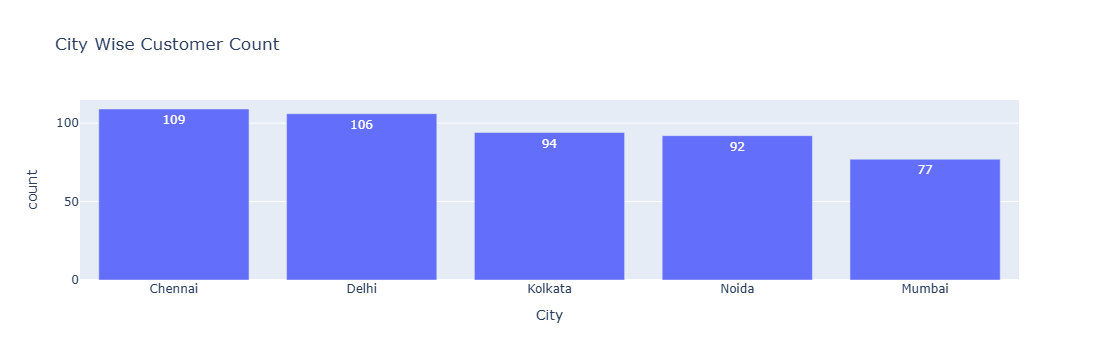

In [19]:
px.bar(data_frame=z2,x='City',y='count',text='count',title='City Wise Customer Count')

#### 1.2 Analysis customer distribution across Age Group.

In [20]:
 cb['Age_Range'] = pd.cut(cb['Age'],bins=[20,23,26,29,32,35,38])

In [21]:
q3 = cb['Age_Range'].value_counts().reset_index()
q3['Age_Range']=q3['Age_Range'].astype(str)
q3

,Age_Range,count
0,"(20, 23]",88
1,"(32, 35]",85
2,"(26, 29]",78
3,"(29, 32]",74
4,"(23, 26]",67
5,"(35, 38]",62


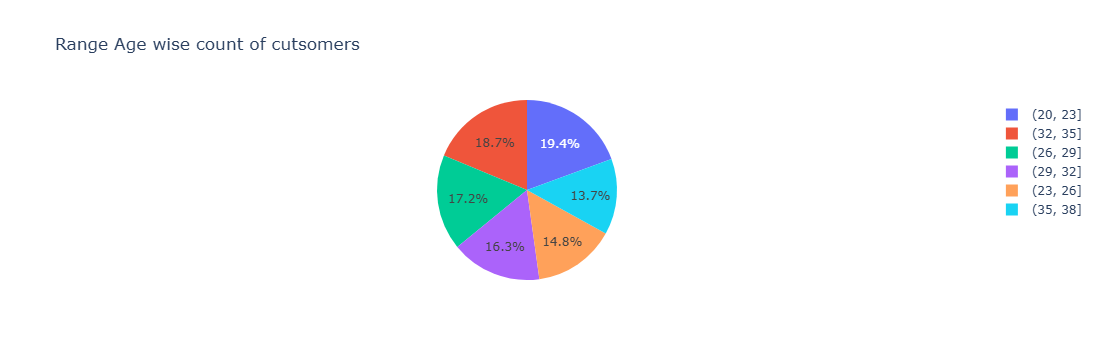

In [22]:
px.pie(data_frame=q3,names='Age_Range',values='count',title='Range Age wise count of cutsomers')

#### 1.3 Evaluation of customer engagement through activity-based analysis.

In [23]:
z1 = ca['Activity'].value_counts().reset_index()
z1

,Activity,count
0,Browse,6548
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


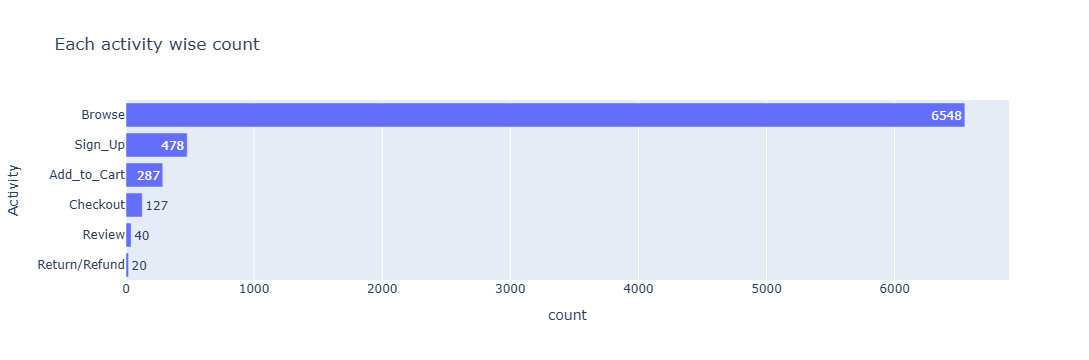

In [40]:
fig = px.bar(data_frame=z1,x='count',y='Activity',text='count', orientation = 'h',title='Each activity wise count')
fig.update_yaxes(autorange="reversed")
fig.show()

#### 1.4 Tracking the monthly revenue trends.

In [25]:
ca_cout = ca[ca['Activity']=='Checkout']

In [26]:
ca_orders_count = pd.merge(orders,ca_cout,on='Cust_ID',how='inner')
ca_orders_count.head()

,Order_id,Cust_ID,Amount,Payment_mode,Activity,Date
0,ORD_71,CUS_545,2123.19,UPI,Checkout,2024-04-26
1,ORD_72,CUS_622,2788.02,Net Banking,Checkout,2024-02-01
2,ORD_73,CUS_418,3071.63,Credit_Card,Checkout,2024-07-22
3,ORD_74,CUS_360,5736.31,COD,Checkout,2025-05-24
4,ORD_75,CUS_714,1592.53,Debit Card,Checkout,2024-06-19


In [27]:
ca_orders_count['Date']=pd.to_datetime(ca_orders_count['Date'])

In [28]:
ca_orders_count['Month']=ca_orders_count['Date'].dt.month

In [29]:
q5 = ca_orders_count.groupby('Month')['Amount'].sum().round(2).reset_index()

In [30]:
q5

,Month,Amount
0,1,27022.20
1,2,70477.42
2,3,74777.59
3,4,88080.66
4,5,60200.46
5,6,69580.07
6,7,80416.05
7,8,27227.29
8,9,34804.62
9,10,30298.38


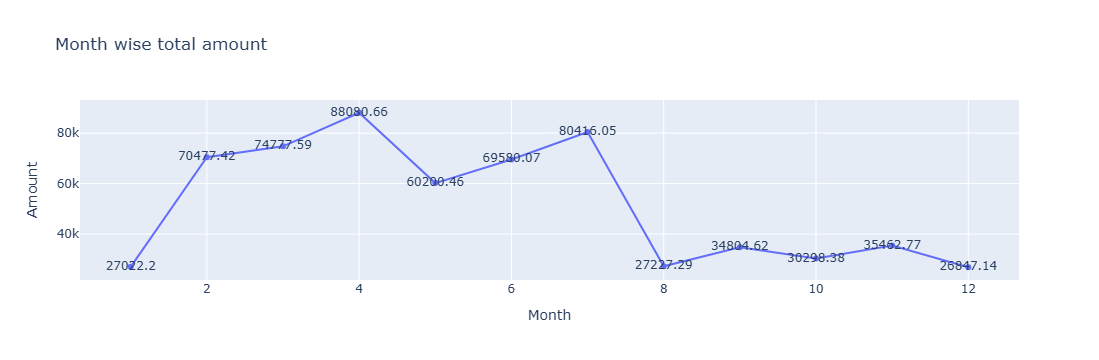

In [31]:
px.line(data_frame=q5,x="Month",y='Amount',text='Amount',title='Month wise total amount')

#### 1.5 Tracking the subscription plan performance.

In [32]:
cs_sp = pd.merge(cs,sp,on='Plan_Var_ID',how='inner')
cs_sp.head()

,Cust_ID,Plan_Var_ID,Purchase_Date,Plan_ID,Plan_name,Price,Duration
0,CUS_626,P1_1Y,2025-05-15,P1,Silver,1200.0,1 Year
1,CUS_723,P1_1Y,2024-07-23,P1,Silver,1200.0,1 Year
2,CUS_575,P1_1Y,2024-11-14,P1,Silver,1200.0,1 Year
3,CUS_232,P2_6M,2025-04-19,P2,Gold,1440.0,6 Months
4,CUS_346,P2_1Y,2024-01-31,P2,Gold,2400.0,1 Year


In [33]:
z5 = cs_sp.groupby(['Plan_name','Duration'])['Price'].sum().sort_values(ascending=False).reset_index()
z5

,Plan_name,Duration,Price
0,Diamond,1 Year,28800.0
1,Diamond,6 Months,25920.0
2,Gold,1 Year,24000.0
3,Silver,1 Year,16800.0
4,Gold,6 Months,7200.0
5,Silver,6 Months,5040.0


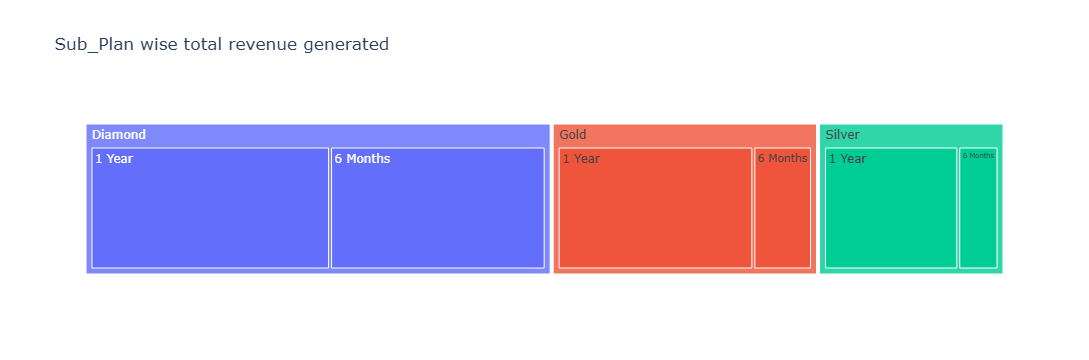

In [35]:
px.treemap(z5,path = ['Plan_name','Duration'],values ='Price',title = 'Sub_Plan wise total revenue generated')

#### 1.6 Regional Revenue Distribution

In [42]:
or_cb = pd.merge(cb,orders,on='Cust_ID',how='inner')
or_cb.head()

,Cust_ID,City,Age,Age_Range,Order_id,Amount,Payment_mode
0,CUS_121,Noida,30,"(29.0, 32.0]",ORD_83,3336.69,UPI
1,CUS_127,Delhi,24,"(23.0, 26.0]",ORD_172,6427.90,Credit_Card
2,CUS_129,Mumbai,20,NaN,ORD_97,8653.62,UPI
3,CUS_135,Kolkata,35,"(32.0, 35.0]",ORD_87,2551.37,Credit_Card
4,CUS_139,Noida,34,"(32.0, 35.0]",ORD_127,3290.14,UPI


In [43]:
z6 = or_cb.groupby('City')['Amount'].sum().sort_values(ascending=False).reset_index()
z6['Amount']=z6['Amount'].round(2)
z6_matrix = z6.set_index('City').T
z6_matrix

City,Noida,Delhi,Mumbai,Kolkata,Chennai
Amount,158552.95,147176.17,120515.98,102185.83,96763.72


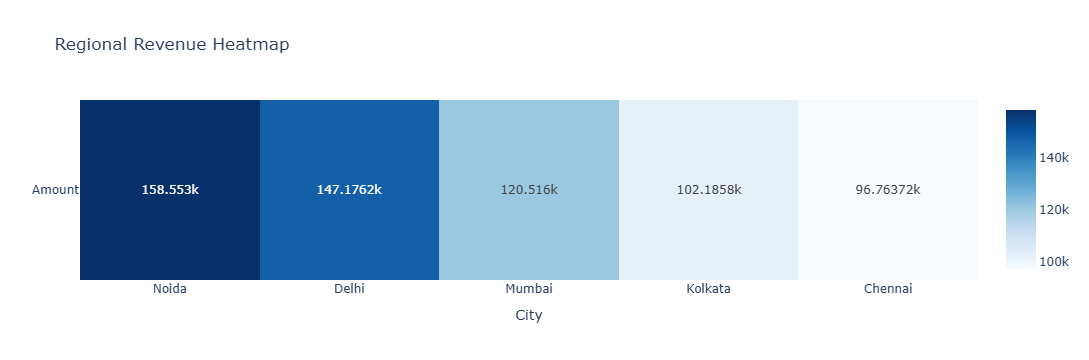

In [45]:
fig = px.imshow(z6_matrix, 
                text_auto=True, 
                aspect="auto", 
                title="Regional Revenue Heatmap",
                color_continuous_scale='Blues')

fig.show()

#### 1.7 Examination of payment behavior.

In [47]:
z7 = orders['Payment_mode'].value_counts().reset_index()
z7

,Payment_mode,count
0,Net Banking,29
1,Debit Card,27
2,UPI,24
3,Credit_Card,24
4,COD,23


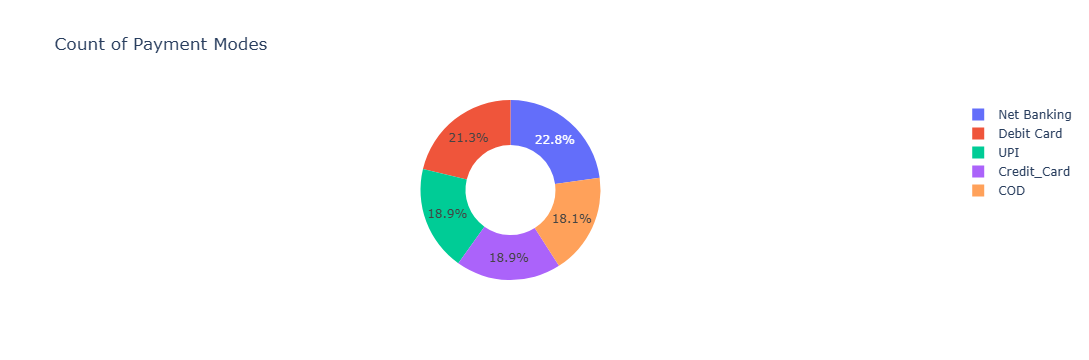

In [48]:
px.pie(data_frame=z7,names='Payment_mode',values='count',hole=0.5,title='Count of Payment Modes')

#### 1.8 Examination of transaction patterns.

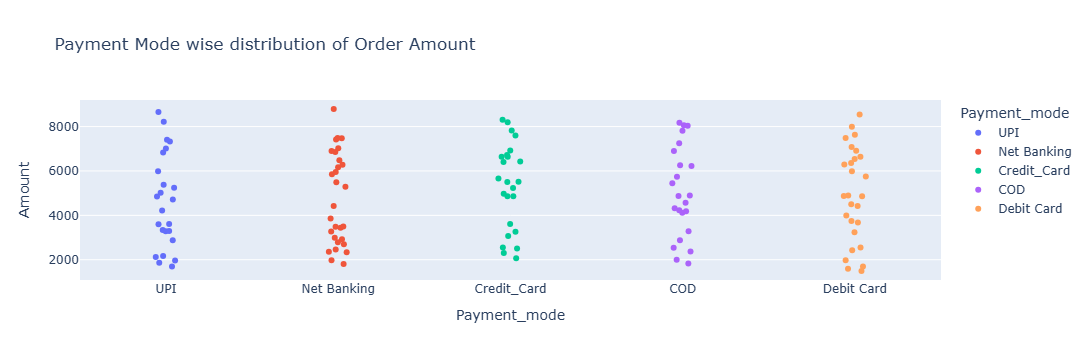

In [49]:
px.strip(data_frame=orders,x='Payment_mode',y='Amount',color='Payment_mode',
         title='Payment Mode wise distribution of Order Amount')

## 2. Funnel Analysis

#### 2.1 Customer Conversion Funnel

In [50]:
f1 = ca.groupby(['Cust_ID','Activity'])['Activity'].count().reset_index(name='count')
f1.head()

,Cust_ID,Activity,count
0,CUS_121,Add_to_Cart,1
1,CUS_121,Browse,8
2,CUS_121,Checkout,1
3,CUS_121,Sign_Up,1
4,CUS_122,Browse,10


In [51]:
funnel = f1['Activity'].value_counts().reset_index()
funnel

,Activity,count
0,Browse,681
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


In [52]:
#lead/lag => df[col].shift()
funnel['perv_count'] = np.where(funnel['Activity']=='Return/Refund',funnel['count'].shift(2),funnel['count'].shift(1))

funnel

,Activity,count,perv_count
0,Browse,681,NaN
1,Sign_Up,478,681.0
2,Add_to_Cart,287,478.0
3,Checkout,127,287.0
4,Review,40,127.0
5,Return/Refund,20,127.0


In [53]:
funnel['percent_conv'] = round((funnel['count']/funnel['perv_count'])*100,2)
funnel.fillna(0,inplace=True)
funnel

,Activity,count,perv_count,percent_conv
0,Browse,681,0.0,0.00
1,Sign_Up,478,681.0,70.19
2,Add_to_Cart,287,478.0,60.04
3,Checkout,127,287.0,44.25
4,Review,40,127.0,31.50
5,Return/Refund,20,127.0,15.75


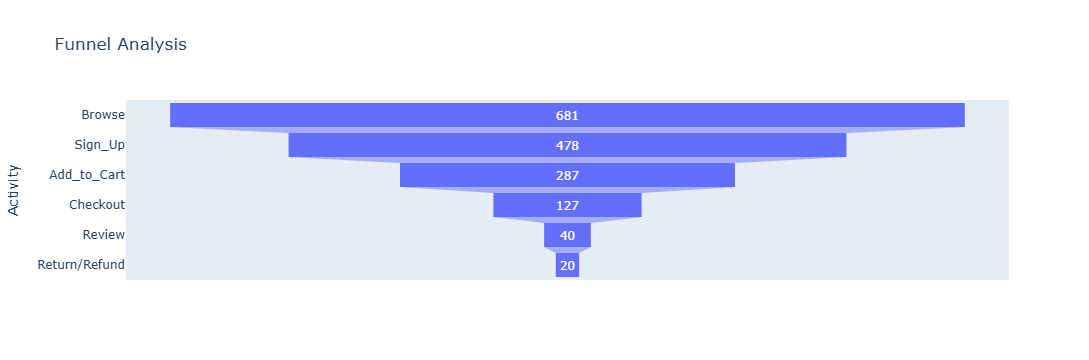

In [54]:
px.funnel(data_frame=funnel,y='Activity',x='count',hover_data='percent_conv',title='Funnel Analysis')

#### 2.2 Customer Average Transition Time

In [55]:
ca.head(17)

,Cust_ID,Activity,Date
0,CUS_121,Sign_Up,2024-04-24
1,CUS_121,Browse,2024-04-27
2,CUS_121,Add_to_Cart,2024-04-27
3,CUS_121,Browse,2024-04-29
4,CUS_121,Browse,2024-04-30
5,CUS_121,Browse,2024-05-04
6,CUS_121,Checkout,2024-05-05
7,CUS_121,Browse,2024-05-07
8,CUS_121,Browse,2024-05-09
9,CUS_121,Browse,2024-05-10


In [56]:
ca['Date']=pd.to_datetime(ca['Date'])

In [57]:
pt1 = pd.pivot_table(data=ca,index=['Cust_ID'],columns=['Activity'],values='Date',aggfunc='min')
pt1.head()

Activity,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up
Cust_ID,,,,,,
CUS_121,2024-04-27,2024-04-27,2024-05-05,NaT,NaT,2024-04-24
CUS_122,NaT,2025-07-12,NaT,NaT,NaT,NaT
CUS_123,NaT,2024-04-14,NaT,NaT,NaT,NaT
CUS_124,2025-01-06,2025-01-06,NaT,NaT,NaT,2025-01-05
CUS_125,NaT,2024-06-17,NaT,NaT,NaT,2024-06-15


In [58]:
#DD = Date difference
pt1['Signup_2Browse_DD'] = abs(pt1['Sign_Up']-pt1['Browse']).dt.days
pt1['Browse_2Add2cart_DD'] = (pt1['Add_to_Cart']-pt1['Browse']).dt.days
pt1['Add2cart_2Checkout_DD'] = (pt1['Checkout']-pt1['Add_to_Cart']).dt.days
pt1['Checkout_2Review_DD'] = (pt1['Review']-pt1['Checkout']).dt.days
pt1['Checkout_2RR_DD'] = (pt1['Return/Refund']-pt1['Checkout']).dt.days

In [59]:
pt1.head()

Activity,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up,Signup_2Browse_DD,Browse_2Add2cart_DD,Add2cart_2Checkout_DD,Checkout_2Review_DD,Checkout_2RR_DD
Cust_ID,,,,,,,,,,,
CUS_121,2024-04-27,2024-04-27,2024-05-05,NaT,NaT,2024-04-24,3.0,0.0,8.0,NaN,NaN
CUS_122,NaT,2025-07-12,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN
CUS_123,NaT,2024-04-14,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN
CUS_124,2025-01-06,2025-01-06,NaT,NaT,NaT,2025-01-05,1.0,0.0,NaN,NaN,NaN
CUS_125,NaT,2024-06-17,NaT,NaT,NaT,2024-06-15,2.0,NaN,NaN,NaN,NaN


In [60]:
pt2 = pt1.iloc[:,-5:]
pt2

Activity,Signup_2Browse_DD,Browse_2Add2cart_DD,Add2cart_2Checkout_DD,Checkout_2Review_DD,Checkout_2RR_DD
Cust_ID,,,,,
CUS_121,3.0,0.0,8.0,NaN,NaN
CUS_122,NaN,NaN,NaN,NaN,NaN
CUS_123,NaN,NaN,NaN,NaN,NaN
CUS_124,1.0,0.0,NaN,NaN,NaN
CUS_125,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...
CUS_797,4.0,NaN,NaN,NaN,NaN
CUS_798,3.0,NaN,NaN,NaN,NaN
CUS_799,NaN,NaN,NaN,NaN,NaN


#### 2.3 Average Duration Between Activity Stages

In [61]:
dd_avg = pt2.mean().reset_index()
dd_avg.columns=['Act_Stages','Avg_Datediff'] 
dd_avg

,Act_Stages,Avg_Datediff
0,Signup_2Browse_DD,2.516736
1,Browse_2Add2cart_DD,0.860627
2,Add2cart_2Checkout_DD,14.425197
3,Checkout_2Review_DD,2.625000
4,Checkout_2RR_DD,3.400000


In [62]:
pt1.columns

Index(['Add_to_Cart', 'Browse', 'Checkout', 'Return/Refund', 'Review',
       'Sign_Up', 'Signup_2Browse_DD', 'Browse_2Add2cart_DD',
       'Add2cart_2Checkout_DD', 'Checkout_2Review_DD', 'Checkout_2RR_DD'],
      dtype='object', name='Activity')

In [63]:
dd_avg['Avg_Datediff'].values

array([ 2.5167364 ,  0.86062718, 14.42519685,  2.625     ,  3.4       ])

In [64]:
avg_dd = [0] + list(dd_avg['Avg_Datediff'].values)
avg_dd

[0,
 np.float64(2.51673640167364),
 np.float64(0.8606271777003485),
 np.float64(14.4251968503937),
 np.float64(2.625),
 np.float64(3.4)]

In [65]:
funnel['Avg_Transition_Days'] = avg_dd
funnel

,Activity,count,perv_count,percent_conv,Avg_Transition_Days
0,Browse,681,0.0,0.00,0.000000
1,Sign_Up,478,681.0,70.19,2.516736
2,Add_to_Cart,287,478.0,60.04,0.860627
3,Checkout,127,287.0,44.25,14.425197
4,Review,40,127.0,31.50,2.625000
5,Return/Refund,20,127.0,15.75,3.400000


#### 2.4 Automated Regional Funnel Analytics

In [66]:
fm = pd.merge(ca,cb,on='Cust_ID',how='inner')
fm.head()

,Cust_ID,Activity,Date,City,Age,Age_Range
0,CUS_121,Sign_Up,2024-04-24,Noida,30,"(29, 32]"
1,CUS_121,Browse,2024-04-27,Noida,30,"(29, 32]"
2,CUS_121,Add_to_Cart,2024-04-27,Noida,30,"(29, 32]"
3,CUS_121,Browse,2024-04-29,Noida,30,"(29, 32]"
4,CUS_121,Browse,2024-04-30,Noida,30,"(29, 32]"


In [67]:
def city_funnel(city):
    funnel = fm[fm['City']==city]['Activity'].value_counts().reset_index()

    funnel['prev_count'] = funnel['prev_count'] = np.where(funnel['Activity']=='Return/Refund', funnel['count'].shift(2), 
                                                           funnel['count'].shift(1))
    funnel['Percent_Conv'] = (funnel['count'] / funnel['prev_count'] * 100).round(2)
    funnel.fillna(0,inplace=True)

    print(f"DATA FOR CITY {city.upper()}")
    print(funnel)

    fig = px.funnel(data_frame=funnel,y='Activity',x='count', hover_data='Percent_Conv',title=f'FUNNEL ANALYSIS FOR CITY {city.upper()}')
    fig.show()

DATA FOR CITY DELHI
        Activity  count  prev_count  Percent_Conv
0         Browse    968         0.0          0.00
1        Sign_Up    106       968.0         10.95
2    Add_to_Cart     60       106.0         56.60
3       Checkout     30        60.0         50.00
4         Review      6        30.0         20.00
5  Return/Refund      4        30.0         13.33


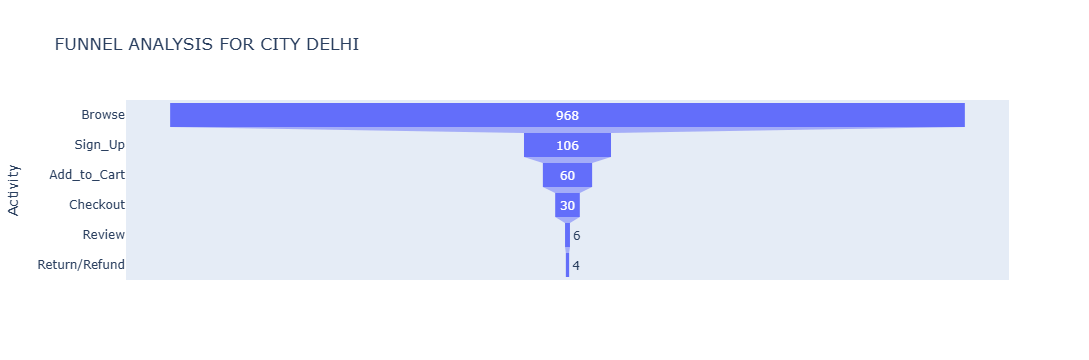

In [68]:
city_funnel('Delhi')

DATA FOR CITY CHENNAI
        Activity  count  prev_count  Percent_Conv
0         Browse   1012         0.0          0.00
1        Sign_Up    109      1012.0         10.77
2    Add_to_Cart     62       109.0         56.88
3       Checkout     18        62.0         29.03
4         Review      9        18.0         50.00
5  Return/Refund      4        18.0         22.22


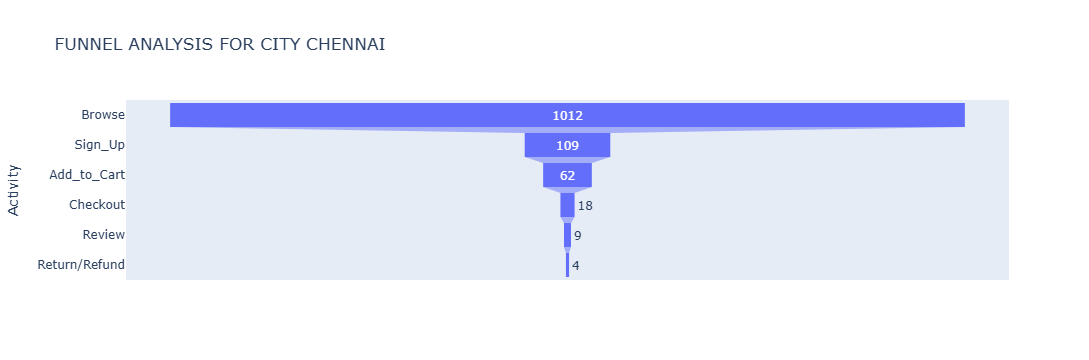

DATA FOR CITY DELHI
        Activity  count  prev_count  Percent_Conv
0         Browse    968         0.0          0.00
1        Sign_Up    106       968.0         10.95
2    Add_to_Cart     60       106.0         56.60
3       Checkout     30        60.0         50.00
4         Review      6        30.0         20.00
5  Return/Refund      4        30.0         13.33


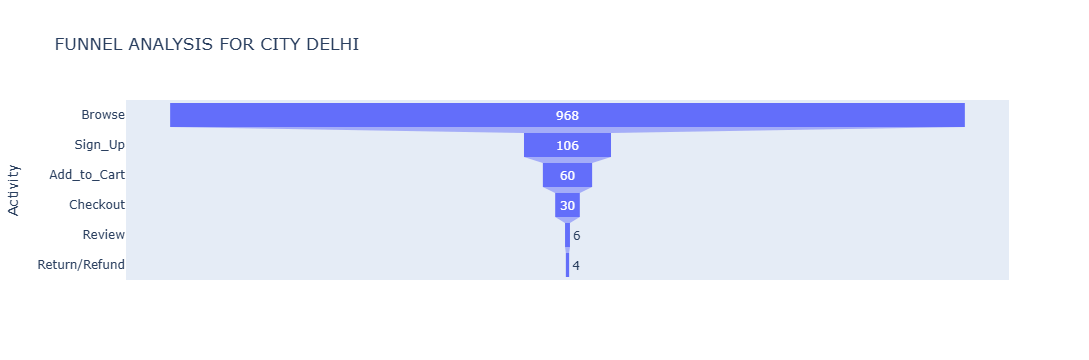

DATA FOR CITY KOLKATA
        Activity  count  prev_count  Percent_Conv
0         Browse    865         0.0          0.00
1        Sign_Up     94       865.0         10.87
2    Add_to_Cart     54        94.0         57.45
3       Checkout     22        54.0         40.74
4         Review      5        22.0         22.73
5  Return/Refund      2        22.0          9.09


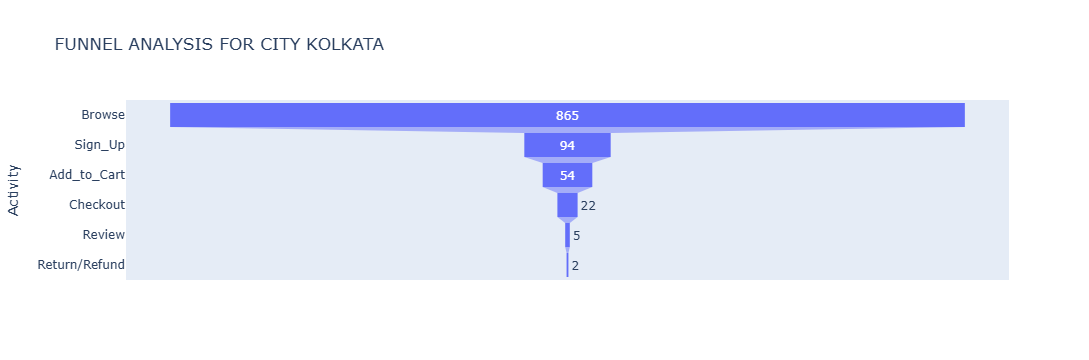

DATA FOR CITY NOIDA
        Activity  count  prev_count  Percent_Conv
0         Browse    797         0.0          0.00
1        Sign_Up     92       797.0         11.54
2    Add_to_Cart     62        92.0         67.39
3       Checkout     34        62.0         54.84
4         Review     10        34.0         29.41
5  Return/Refund      6        34.0         17.65


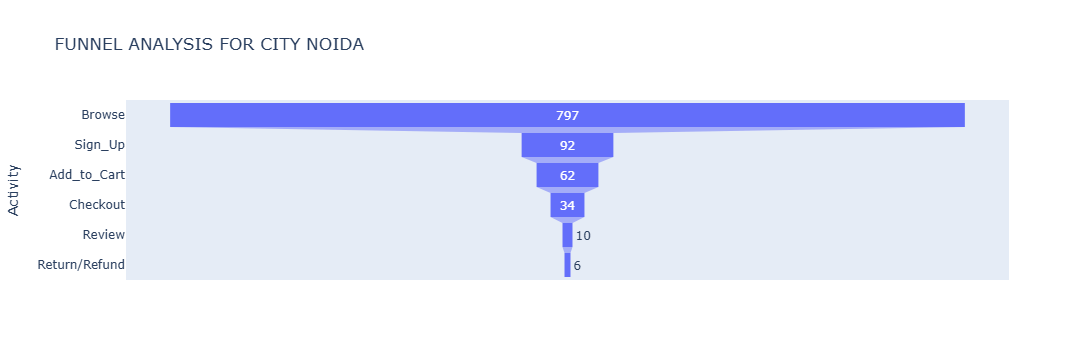

DATA FOR CITY MUMBAI
        Activity  count  prev_count  Percent_Conv
0         Browse    685         0.0          0.00
1        Sign_Up     77       685.0         11.24
2    Add_to_Cart     49        77.0         63.64
3       Checkout     23        49.0         46.94
4         Review     10        23.0         43.48
5  Return/Refund      4        23.0         17.39


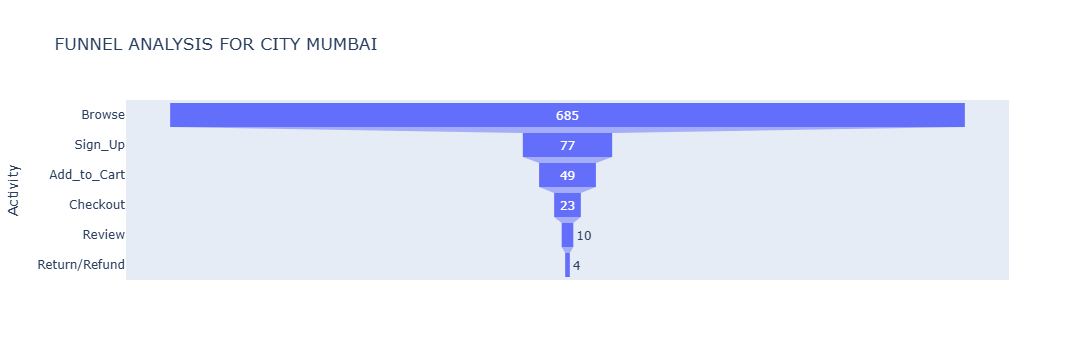

In [69]:
cities = ['Chennai','Delhi','Kolkata','Noida','Mumbai']
for i in cities:
    city_funnel(i)

### Conclusion:

This project analyzed the customer conversion funnel to understand user behavior, revenue trends, and conversion performance.<br> 
Through EDA and funnel analysis, key customer drop-off points and business insights were identified, enabling data-driven decisions<br> 
to improve customer engagement, conversions, and revenue growth.